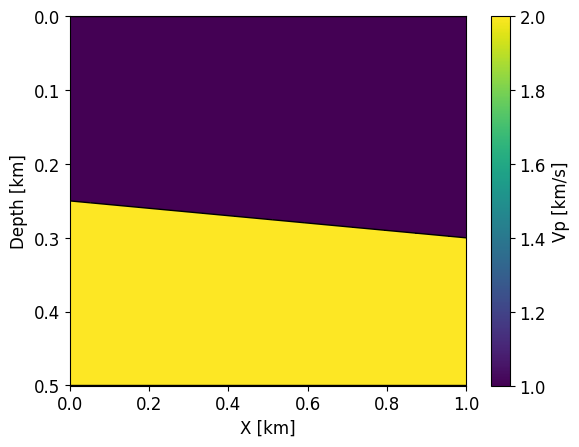

In [1]:
import numpy as np
import xarray as xr
from frequensolve import *

project_path = "./scratch/ex_04/"
project = Project(
    name = "project",
    pretty_name = "DAS Simulation",
    path = project_path,
)

sim = project.new_simulation(
    name      = "simulation_1",
    physics   = "coupled",
    dimension = 2
)

# --- Model ---

# New 2D layered model over interval x in [0,1]
model = LayeredModel(dimension = 2, x_limits = [0.0, 1.0])

model.add_surface(name = "top", z = 0.0)
model.add_layer(
    name = "layer_1",
    properties = { 
        "Vp" : 1.0,
        "Qp" : 100.0,
        "Vs" : 0.5,
        "Qs" : 100.0,
        "Rho": 1.0
    }
)

model.add_surface(
    name = "interface", 
    z = xr.DataArray(
        [0.25, 0.3], 
        dims = ["x"], 
        coords = {"x" : [0.0, 1.0]}
    )
)

model.add_layer(                    # Layer 2 
    name = "layer_2",
    properties = { 
        "Vp" : 2.0,
        "Qp" : 100.0,
        "Vs" : 1.0,
        "Qs" : 100.0,
        "Rho": 1.0 
    }
)
model.add_surface(name = "bottom", z = 0.5)

model.plot("Vp")
sim += model

# --- Mesh ---
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(
    min_epw = 2.0,
    adapt_sources = 0
)

# --- Boundary Conditions ---
BCs = BoundaryConditionManager(label_type = "geometric")
BCs += BoundaryCondition(
    name = "free_surface",
    kind = "free",
    boundaries = ["z_min"]
)
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max"],
    pml_wavelengths = 1.0,
    pml_exponent = 3.0,
    pml_constant = 3.0
)
sim += BCs

In [2]:

# --- Acquisition ---
acq = Acquisition()

# define source
acq.add_source_group(kind = "vector",
                     coords = [[0.5, 0.0]],
                     direction = [0.0, 1.0])

# surface geophones
geophone = ReceiverNode(name = "geophone")
geophone.add_component("u_z","displacement",[0.0, 1.0])

coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 1001)]
acq.add_receiver_group(
    name = "surface_geophones",
    device = geophone,
    coords = coords,
    frame = "reference"
)

# downhole DAS
das = ReceiverFiber(
    name = "fiber",
    L_gauge = 0.01,
    n_gauge = 100,
    radius = 0.001,
    pitch = 0.005
)
das.add_component("eps_tt", "strain")

# coords = [ [0.25, z] for z in np.linspace(0.0, 0.5, 101)]
n_turns = 3
r0 = 0.2
rf = 0.4 
z0 = 0.05
zf = 0.55
n_pts = 51
coords = []
for i, t in enumerate(np.linspace(0.0, 1.0, n_pts)):
    theta = n_turns * 2 * np.pi * t
    r = r0 + (rf - r0) * t
    x = 0.5 + r * np.cos(theta)
    z = z0 + (zf - z0) * t + 0.01*np.sin(10*theta)  # add some small oscillation to z
    coords.append([x, z])

acq.add_receiver_group(
    name = "well_das",
    device = das,
    coords = coords,
    frame = "physical"
)
sim += acq

# --- Discretization ---
sim += Discretization(order = 4)
sim += SolverConfig(tolerance = 1.0e-4, grids = 3, kwargs = {"ptol": 1.e-10})

out = OutputManager()
out += ParaviewOutput(
    name = "das", 
    fields = ["displacement", "velocity", "pressure"],
    properties = ["Vp", "Subdomain", "div"],
    upscale = 0,
)
sim += out

project.save()

PosixPath('/Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_04/project.json')

Dask initialized with 1 workers, 16 threads per worker, and 117964MB memory per worker


INFO: Dask dashboard initialized successfully
INFO: Task stream initialized successfully


Dask Dashboard available at: http://localhost:51459/status


INFO: Executing: /Users/jacobbadger/omnirepo/FS_solver/FS_seismic -nthreads 1 -j /Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_04/jobs/simulation_1/freq/freq.json -i 0
INFO: Executing: /Users/jacobbadger/omnirepo/FS_solver/FS_seismic -nthreads 16 -j /Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_04/jobs/simulation_1/freq/freq.json -i 1


Running: freq 0/1 |          | Elapsed time: 00:00s

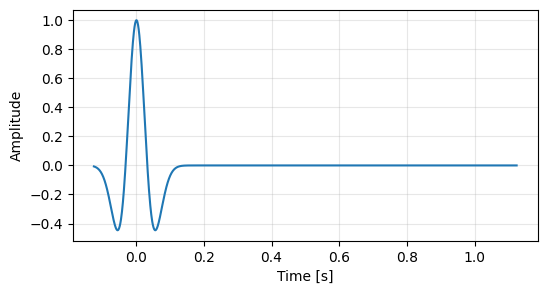

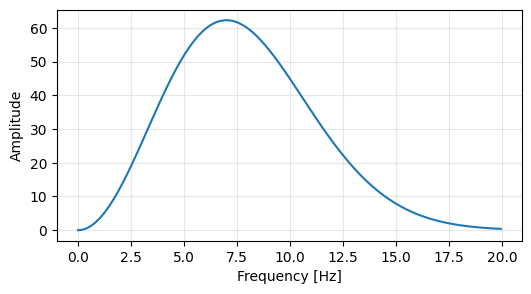

surface_geophones
  Receivers	: 1 - 1001
  Shot		: 1
  Components	: ['u_z']
  Frequencies	: 1.00 - 20.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s

well_das
  Receivers	: 1 - 1001
  Shot		: 1
  Components	: ['eps_tt']
  Frequencies	: 1.00 - 20.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s




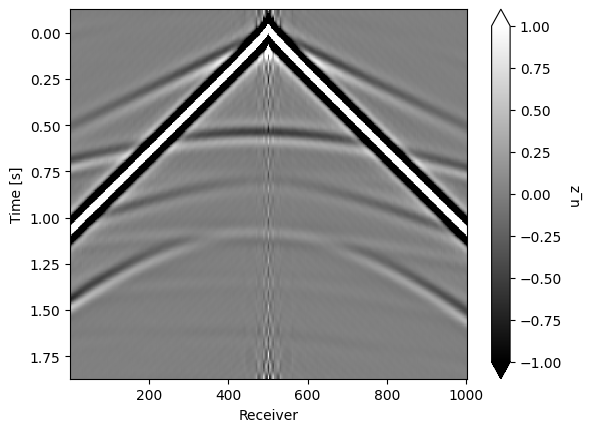

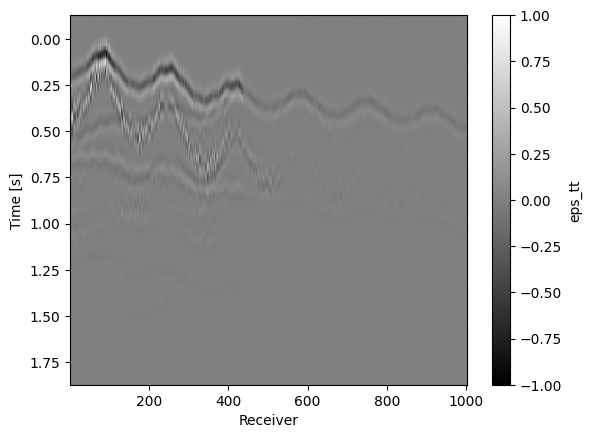

In [3]:
# --- Connect to site ---
site = LocalSite()
site.sync(project)

# Create and submit frequency domain job
job = TimeDomainJob(
    name = "td_job",
    simulation = sim,
    f_min = 1.0,
    f_max = 20.0,
    T_max = 2.0
)

fd_job = FrequencyDomainJob(
    name = "freq",
    simulation = sim,
    f_list = [30.0 - 0.1j],
)
site.submit(fd_job)
trace_db = site.fetch_traces(job, upscale = 4)

wavelet = RickerWavelet(
    f = 7, 
    center = 0.125
)
wavelet.plot(f_max = 20.0)

print(trace_db)
for group in trace_db.groups:
    for shot in trace_db.shots(group):
        for comp in trace_db.components(group):
            td = trace_db.read_TD(group, comp, shot, wavelet, upscale = 4)
            plot = td.real.plot(
                vmin = -1, 
                vmax = 1, 
                y = "time", 
                yincrease = False,
                cmap = "gray"
            )
            plt.show()